In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/usr/local/python/3.12.1/lib/python3.12/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([100, 1])) that is different to the input size (torch.Size([100])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch 0 and loss = 5752.92236328
epoch 1000 and loss = 5664.85546875
epoch 2000 and loss = 5663.30029297
epoch 3000 and loss = 5663.27197266
epoch 4000 and loss = 5663.27099609
epoch 5000 and loss = 5663.27050781
epoch 6000 and loss = 5663.27099609
epoch 7000 and loss = 5663.27099609
epoch 8000 and loss = 5663.27099609
epoch 9000 and loss = 5663.27099609


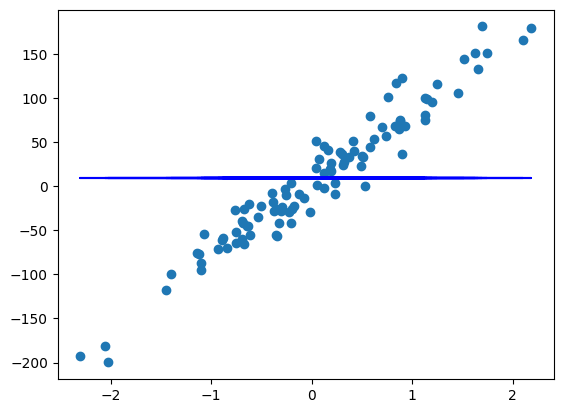

In [2]:
from sklearn.datasets import make_regression
x_numpy,y_numpy=make_regression(n_samples=100,n_features=1,n_targets=1,noise=20,random_state=1)
df=pd.DataFrame(x_numpy,columns=['Features'])
df['target']=y_numpy
x=torch.from_numpy(x_numpy.astype(np.float32))
y=torch.from_numpy(y_numpy.astype(np.float32))
n_samples,n_features=x.shape

# model
input_size=n_features
output_size=1
model=nn.Linear(input_size,output_size)

# loss and optimizer
criterion=nn.MSELoss()
learning_rate=0.001
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

# training 
num_epochs=10000
for epoch in range(num_epochs):
    # forward pass and loss
    y_predicted=model(x)
    loss=criterion(y,y_predicted)
    # backward pass
    loss.backward()
    #update parameters
    optimizer.step()
    optimizer.zero_grad()
    if epoch % 1000 == 0:
        print(f"epoch {epoch} and loss = {loss:.8f}")


predicted=model(x).detach().numpy()
plt.scatter(x_numpy,y_numpy)
plt.plot(x_numpy,predicted,'b')
plt.show()